## Ce projet a été réalisé par : 
### - `Youness EL HACHIMI`

# Quelques Modules Pour l'analyse 

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn
from scipy.stats import norm

# des modules utiles pour les test et la modélisation
from scipy import stats
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Chargement du dataset

In [3]:
df = pd.read_csv("adult.csv")

## Affichage de l'en-tête

In [4]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [5]:
df.sample(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
6280,57,Private,205708,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,Poland,<=50K
11463,28,Private,144521,HS-grad,9,Never-married,Other-service,Own-child,Black,Female,0,0,40,United-States,<=50K
5579,51,Private,154342,7th-8th,4,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,<=50K
14620,31,Private,142038,HS-grad,9,Married-civ-spouse,Craft-repair,Wife,White,Female,0,0,45,United-States,<=50K
17705,71,Local-gov,229110,HS-grad,9,Widowed,Exec-managerial,Other-relative,White,Female,0,0,33,United-States,<=50K
27626,41,Private,178431,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,Taiwan,<=50K
11158,26,Private,212304,7th-8th,4,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,48,United-States,<=50K
18578,39,Private,248694,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,60,United-States,<=50K
23476,38,Private,164898,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
32280,31,Private,188246,Assoc-acdm,12,Divorced,Craft-repair,Not-in-family,White,Male,0,0,50,United-States,>50K


In [6]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,43,Self-emp-not-inc,27242,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K
32552,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32553,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32554,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32555,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Déterminez la forme du dataset

In [7]:
print(df.shape)

(32561, 15)


## Informations sur le dataset

In [8]:
result = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Affichage des types de variables 

In [9]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

## Nettoyage

- ### Vérifier les valeurs nulles

In [10]:
# Cherchons les valeurs nulles
df.isna().sum() 

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

### Valeurs manquantes

In [11]:
# On compte combien de '?' on a dans le dataset
df.isin(["?"]).sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Dans les colonnes **`workclass`**, **`occupation`** et **`native.country`**, la valeur `'?'` ne correspond pas à une catégorie valide.  
Elle doit donc être considérée comme une **valeur manquante** et traitée en conséquence lors du prétraitement des données (suppression, imputation, etc.)

In [12]:
# Remplacons '?' par NaN 
# Parce que pandas le traite comme une valeur valide alors qu'il s'agit d'une information manquante dans notre dataset
df.replace("?", np.nan, inplace=True) 

- ### Supression des valeurs manquantes

In [13]:
print(f"Shape du dataset avant suppression des valeurs manquantes : {df.shape}")

Shape du dataset avant suppression des valeurs manquantes : (32561, 15)


In [14]:
# Suppression de toutes les lignes contenant des valeurs manquantes,
# car elles ne sont pas pertinentes pour l'analyse
df.dropna(inplace=True)

<Axes: >

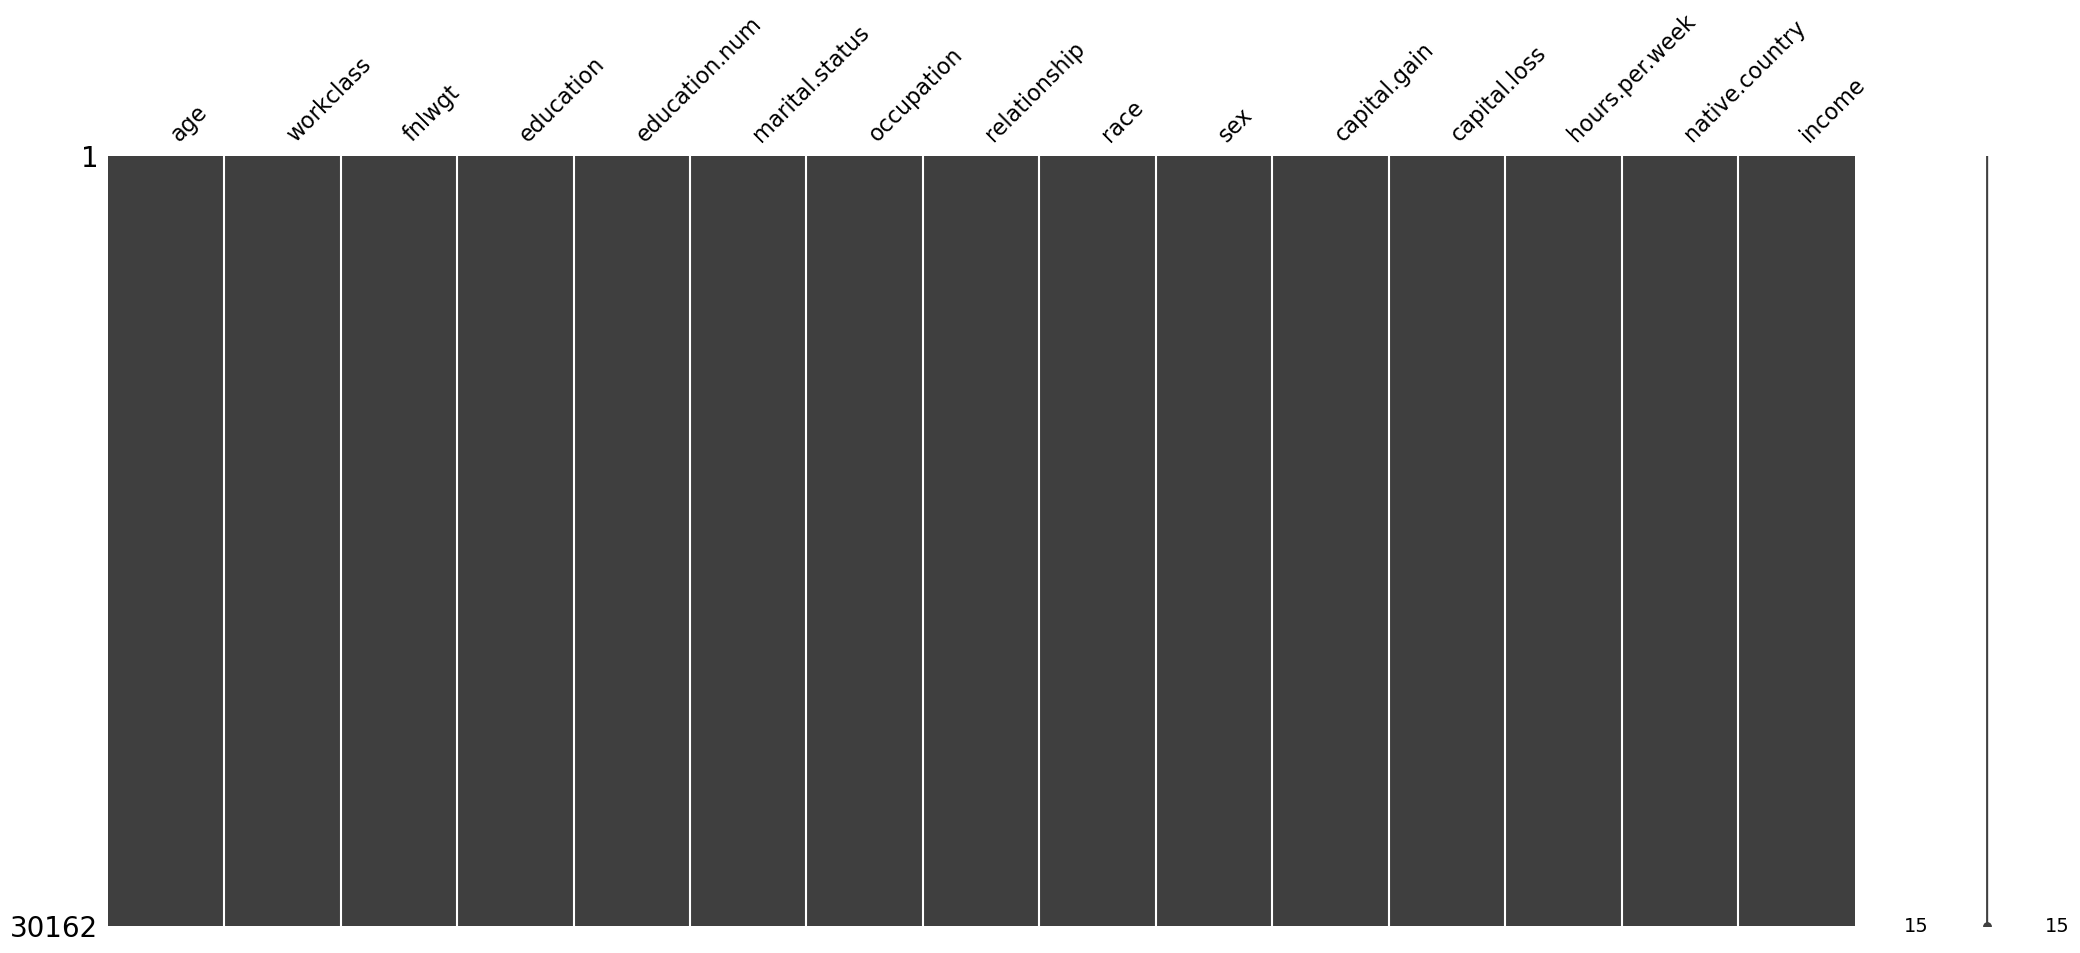

In [15]:
msn.matrix(df)

- ### Suppression des valeurs dupliqué

In [16]:
print(f"Shape du dataset avant suppression des doublons : {df.shape}")

Shape du dataset avant suppression des doublons : (30162, 15)


In [17]:
# Calcule de nombre de valeurs non manquantes dans chaque colonne
# après suppression des lignes contenant des valeurs manquantes
df.dropna().count()

age               30162
workclass         30162
fnlwgt            30162
education         30162
education.num     30162
marital.status    30162
occupation        30162
relationship      30162
race              30162
sex               30162
capital.gain      30162
capital.loss      30162
hours.per.week    30162
native.country    30162
income            30162
dtype: int64

In [18]:
# Détection et comptage des lignes dupliquées dans notre dataset
df.duplicated().sum()

np.int64(23)

On constate que le dataset contient des **lignes dupliquées**, ce qui peut affecter la **qualité de l’analyse**.
À cette étape, nous supprimons donc les **doublons** afin d’assurer une analyse plus **fiable et efficace**.

In [19]:
df = df.drop_duplicates()

In [20]:
print(f"Shape du dataset après suppression des doublons : {df.shape}")

Shape du dataset après suppression des doublons : (30139, 15)


In [21]:
df.dropna().count()

age               30139
workclass         30139
fnlwgt            30139
education         30139
education.num     30139
marital.status    30139
occupation        30139
relationship      30139
race              30139
sex               30139
capital.gain      30139
capital.loss      30139
hours.per.week    30139
native.country    30139
income            30139
dtype: int64

<center>
    <h1>Analyse Univariée et Multivariée</h1>
</center>

- ### Description du dataset après nettoyage

In [22]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,30139.000000,3.013900e+04,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,1.897950e+05,10.122532,1092.841202,88.439928,40.934703
std,13.131426,1.056586e+05,2.548738,7409.110596,404.445239,11.978753
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176275e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376045e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


- ### Variable cible (variable d’intérêt)

Dans le dataset **Adult**, la variable cible est :

- **`income`** : indique si le revenu annuel d’un individu est :
  - **`<=50K`** → **0**
  - **`>50K`** → **1**

> **Objectif :** analyser les facteurs socio-économiques qui influencent le niveau de revenu.

## Analyse Univariée (Une seule variable) :

- ### Catégories uniques pour chaque colonne

In [23]:
Cat_var = list(df.columns[df.dtypes=="object"])
for i in Cat_var:
    print(i)
    unique = pd.unique(df[i])
    print(unique)
    print("=====================================")

workclass
['Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay']
education
['HS-grad' '7th-8th' 'Some-college' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-voc' '1st-4th' '5th-6th' 'Assoc-acdm'
 '12th' '9th' 'Preschool']
marital.status
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation
['Exec-managerial' 'Machine-op-inspct' 'Prof-specialty' 'Other-service'
 'Adm-clerical' 'Transport-moving' 'Sales' 'Craft-repair'
 'Farming-fishing' 'Tech-support' 'Protective-serv' 'Handlers-cleaners'
 'Armed-Forces' 'Priv-house-serv']
relationship
['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']
race
['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']
sex
['Female' 'Male']
native.country
['United-States' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' 'Canada' 'South' 'Holand-Net

- ### Suppression des colonnes inutiles pour la clarté

In [24]:
# On supprime 'fnlwgt' car c'est une pondération statistique (poids de l'échantillon) 
# et non une caractéristique utile pour prédire le revenu d'une personne.
df.drop(columns=['fnlwgt'], inplace=True)

# Native.country car Plus de 90% des données proviennent des États-Unis ("United-States"),
# Alors ce variable n'apporte aucune variance utile pour expliquer le changement de revenu car tous la majorite de  personnes sont de USA
df.drop(columns=['native.country'], inplace=True)

# Relationship car Cette variable est fortement corrélée avec marital.status et sex , donc juste une duplication
df.drop(columns=['relationship'], inplace=True)

- ### Analyse de Variables Catégoriques

In [25]:
from IPython.display import display, Markdown

Cat_Var = df.select_dtypes(include=['object']).columns

for col in Cat_Var:
    counts = df[col].value_counts()
    percent = (df[col].value_counts(normalize=True) * 100)
    
    summary = pd.DataFrame({
        'Effectif': counts,
        'Proportion (%)': percent
    })

    display(Markdown(f"### 📊 Analyse de la variable : **{col.upper()}**"))
    
    print(f"Nombre de valeurs uniques : {df[col].nunique()}")
    print(f"Valeur dominante : '{counts.index[0]}' ({percent.max():.1f}%)")
    
    styled_df = summary.style.format({'Proportion (%)': "{:.2f}%"})\
                             .bar(subset=['Proportion (%)'], color='#79aec8', vmin=0, vmax=100)\
                             .set_properties(**{'text-align': 'left', 'border': '1px solid #dee2e6'})\
                             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#062039')]}])
    
    display(styled_df)
    display(Markdown("---"))

### 📊 Analyse de la variable : **WORKCLASS**

Nombre de valeurs uniques : 7
Valeur dominante : 'Private' (73.9%)


,Effectif,Proportion (%)
workclass,,
Private,22264,73.87%
Self-emp-not-inc,2498,8.29%
Local-gov,2067,6.86%
State-gov,1279,4.24%
Self-emp-inc,1074,3.56%
Federal-gov,943,3.13%
Without-pay,14,0.05%


---

### 📊 Analyse de la variable : **EDUCATION**

...

---

### 📊 Analyse de la variable : **INCOME**

Nombre de valeurs uniques : 2
Valeur dominante : '<=50K' (75.1%)


,Effectif,Proportion (%)
income,,
<=50K,22633,75.10%
>50K,7506,24.90%


---

- ### Interprétation des variables qualitatives

  ### Secteur d’activité (`workclass`)
    - **Observation** : Le secteur **Private** est largement dominant avec **21 218 individus**.
    - **Conclusion** : L’échantillon est majoritairement composé de salariés du **secteur privé**. Les **fonctionnaires** (Gov) ainsi que les **travailleurs indépendants** sont faiblement représentés.


  ### Niveau d’études (`éducation`)
    - **Observation** : Les niveaux d’études les plus fréquents sont :
      - **HS-grad** : 9 389  
      - **Some-college** : 6 442  
      - **Bachelors** : 4 864  
    - **Conclusion** : La majorité de la population possède un **niveau d’études secondaire** ou un **premier cycle universitaire**. Les niveaux avancés (**Masters**, **Doctorate**) restent marginaux.


  ### Répartition des revenus (`income`)
  - **Observation** :  
    - **≤ 50K** : 21 287 individus  
    - **> 50K** : 7 191 individus  
  - **Conclusion** : La distribution des revenus est **fortement déséquilibrée**, avec une prédominance des individus percevant un revenu **inférieur ou égal à 50K**.

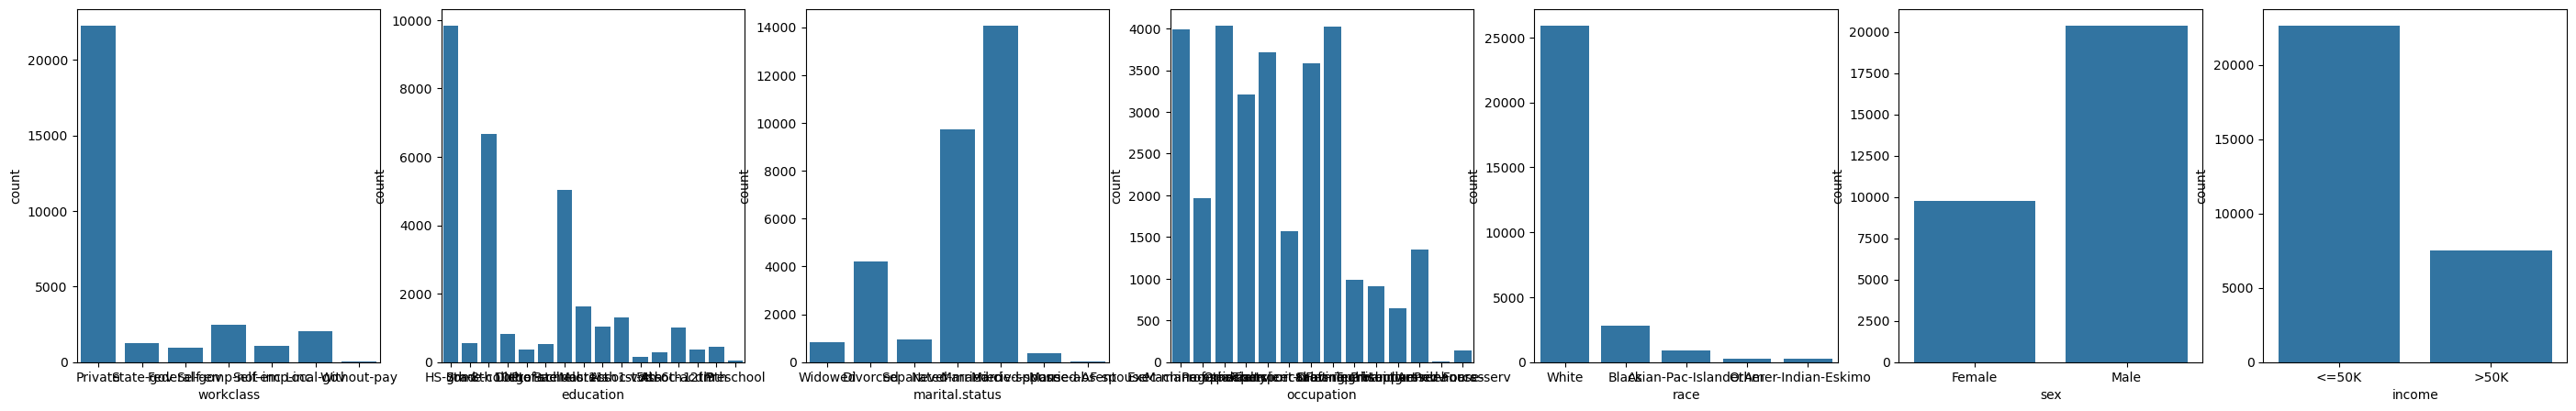

In [26]:
_,axs = plt.subplots(1,len(Cat_Var), figsize =(35,5))
c = 0
for i in Cat_Var:
    sns.countplot(x = i, data=df, ax = axs[c])
    c+=1

In [27]:
print("Données prêtes :", df.shape)

Données prêtes : (30139, 12)


In [28]:
# Conversion de la cible en numérique (0 et 1) pour les calculs
df['income_num'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [29]:
df.describe()

,age,education.num,capital.gain,capital.loss,hours.per.week,income_num
count,30139.000000,30139.000000,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,10.122532,1092.841202,88.439928,40.934703,0.249046
std,13.131426,2.548738,7409.110596,404.445239,11.978753,0.432468
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


- ### Sélection des Variables d'Intérêt

    Suite à une exploration globale du dataset, nous avons choisi de concentrer notre étude approfondie sur trois variables **quantitatives** :
    -  **L'Âge** (`age`)
    -  **Le nombre d'années d'éducation** (`education.num`)
    -  **Le temps de travail hebdomadaire** (`hours.per.week`)

    **Justification du choix :**
    Ce choix est motivé par leur **forte pertinence théorique** pour expliquer les variations de revenu (*Income*). De plus, leur nature numérique nous permet d'étudier leur distribution, de tester leur adéquation avec des **lois de probabilités** connues (comme la loi Normale) et de réaliser des tests statistiques rigoureux.

---

### 1. Variable âge (age)

In [30]:
df["age"].describe()


count    30139.000000
mean        38.441720
std         13.131426
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64

### Interprétation

- **Profil démographique** : La population est majoritairement jeune et active, avec une **moyenne d’âge de 38,4 ans** et une **médiane de 37 ans**.  
- **Dispersion** : L’écart-type est de **13 ans**, indiquant une distribution relativement équilibrée entre jeunes actifs et travailleurs expérimentés.  
- **Forme de la distribution** : La courbe est **asymétrique à droite**, ce qui est cohérent puisque le nombre d’individus diminue naturellement à l’approche de l’âge de la retraite.  

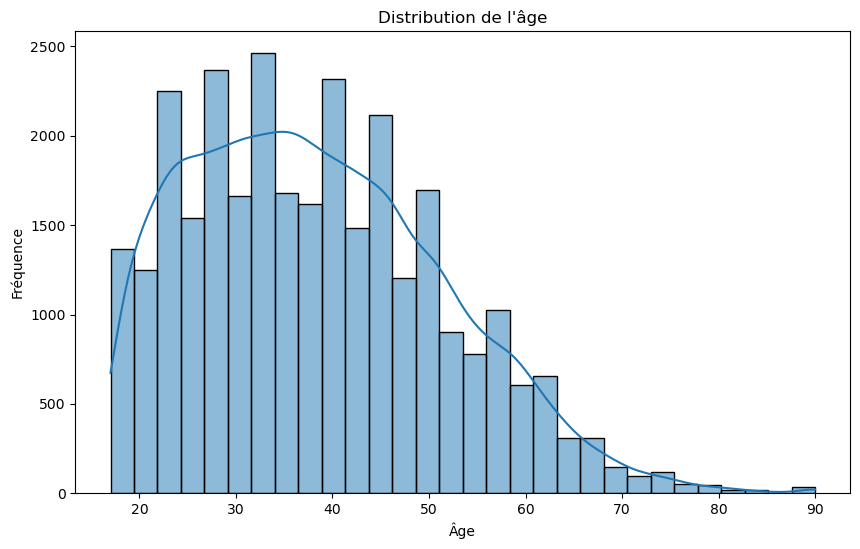

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(df["age"], bins=30, kde=True)
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.title("Distribution de l'âge")
plt.show()


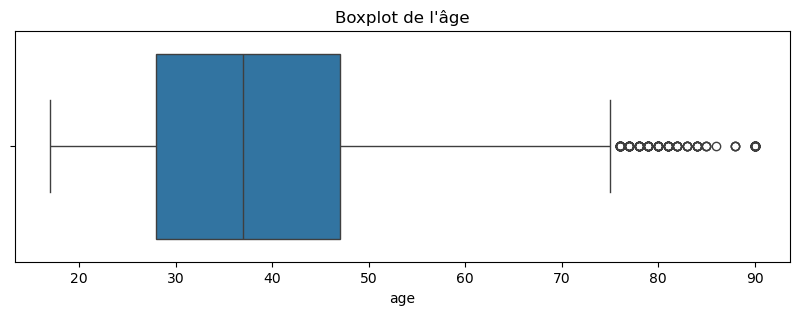

In [32]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df["age"])
plt.title("Boxplot de l'âge")
plt.show()

In [35]:
# Les valeurs aberrantes
z_scores = np.abs(stats.zscore(df["age"]))
df[z_scores > 2.5]

,age,workclass,education,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income,income_num
1,82,Private,HS-grad,9,Widowed,Exec-managerial,White,Female,0,4356,18,<=50K,0
7,74,State-gov,Doctorate,16,Never-married,Prof-specialty,White,Female,0,3683,20,>50K,1
47,73,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Farming-fishing,Asian-Pac-Islander,Male,0,2457,40,<=50K,0
113,72,Self-emp-not-inc,Doctorate,16,Married-civ-spouse,Prof-specialty,White,Male,0,2392,25,>50K,1
116,78,Self-emp-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,White,Male,0,2392,40,>50K,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31904,80,Self-emp-not-inc,7th-8th,4,Never-married,Farming-fishing,White,Male,0,0,20,<=50K,0
31939,82,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Farming-fishing,White,Male,0,0,20,<=50K,0
32305,90,Private,HS-grad,9,Widowed,Adm-clerical,White,Female,0,0,25,<=50K,0
32364,75,Self-emp-not-inc,Masters,14,Widowed,Sales,White,Male,0,0,45,<=50K,0


### Interprétation

- `Résultat` : 329 individus sont identifiés comme atypiques sur un total de plus de 30 000.

- `Profil` : Il s'agit principalement des seniors (75 à 90 ans) qui continuent de travailler .


---

### 2. Heures travaillées (hours.per.week)


In [36]:
df["hours.per.week"].describe()


count    30139.000000
mean        40.934703
std         11.978753
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours.per.week, dtype: float64

### Interprétation

- **Norme sociale** : La distribution des heures de travail montre une **forte concentration à 40 heures par semaine**, avec une **moyenne de 40,9 heures** et une **médiane de 40 heures**, reflétant la prédominance des contrats à plein temps.  
- **Dispersion** : L’écart-type est d’environ **12 heures**, indiquant que certaines personnes travaillent **beaucoup plus ou beaucoup moins que la moyenne**.  
- **Conclusion** : La distribution est **centrée sur le travail à plein temps**, avec quelques valeurs extrêmes représentant des cas atypiques.  


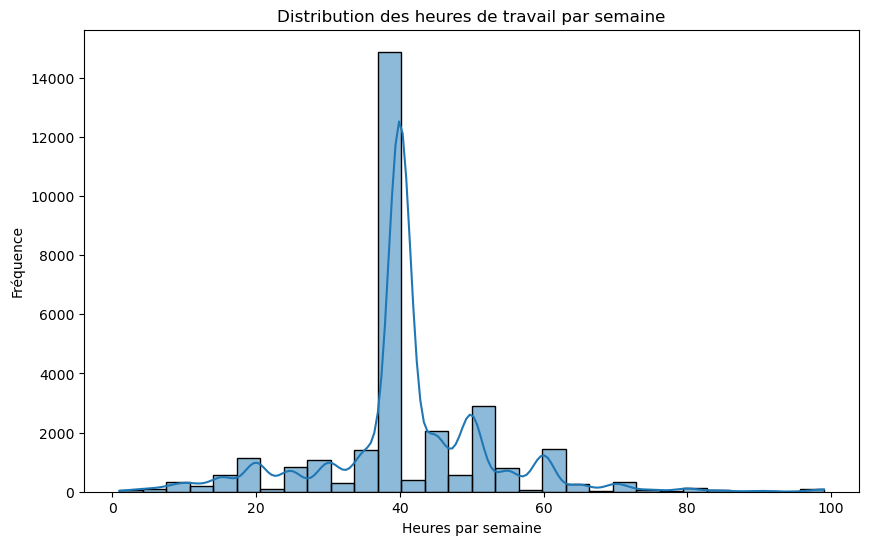

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['hours.per.week'], bins=30, kde=True)
plt.xlabel("Heures par semaine")
plt.ylabel("Fréquence")
plt.title("Distribution des heures de travail par semaine")
plt.show()

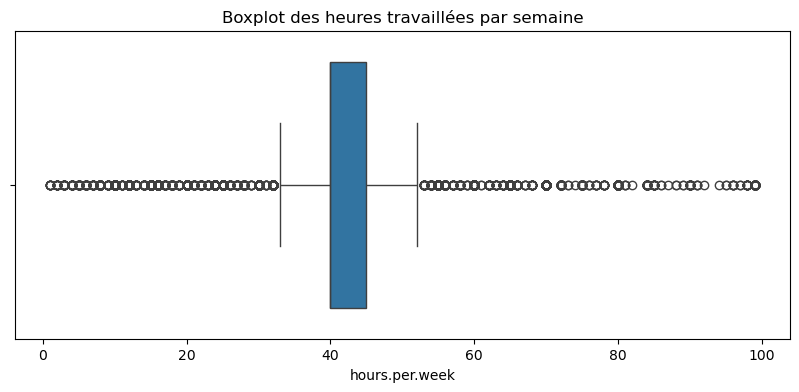

In [38]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["hours.per.week"])
plt.title("Boxplot des heures travaillées par semaine")
plt.show()


In [39]:
z_scores = np.abs(stats.zscore(df["hours.per.week"]))
df[z_scores > 2.5]

,age,workclass,education,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income,income_num
16,45,Private,11th,7,Divorced,Transport-moving,White,Male,0,2824,76,>50K,1
29,38,Private,10th,6,Never-married,Prof-specialty,White,Male,0,2559,90,>50K,1
51,50,Private,HS-grad,9,Widowed,Sales,White,Female,0,2444,72,>50K,1
62,44,Private,Some-college,10,Married-civ-spouse,Adm-clerical,White,Female,0,2415,6,>50K,1
81,60,Self-emp-inc,Prof-school,15,Married-civ-spouse,Prof-specialty,White,Male,0,2415,80,>50K,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32409,55,Private,HS-grad,9,Separated,Protective-serv,White,Male,0,0,81,<=50K,0
32417,42,Private,Some-college,10,Married-civ-spouse,Craft-repair,White,Male,0,0,89,>50K,1
32446,36,Private,Preschool,1,Divorced,Other-service,Other,Male,0,0,72,<=50K,0
32468,85,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,White,Male,0,0,3,<=50K,0


### Interprétation

- **Nombre d’extrêmes** : Le code a détecté **`968 individus`** dont le temps de travail hebdomadaire est **très éloigné de la moyenne** $Z > 2,5$  
- **Nature des extrêmes** : Ces valeurs correspondent à des **situations atypiques** du marché du travail :  
  - Contrats très courts (ex. 11 h/semaine)  
  - Durées de travail très longues (plus de 70–80 h/semaine)  
- **Distribution** : Contrairement à la variable âge, cette variable présente **beaucoup `d’outliers`**, montrant une distribution **asymétrique et plus dispersée** autour de la moyenne.  

---

### 3. Niveau d’éducation (education.num)

In [40]:
df["education.num"].describe()


count    30139.000000
mean        10.122532
std          2.548738
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education.num, dtype: float64

### Interprétation

- **Moyenne (~10 années)** : En moyenne, les individus ont environ **10 années d’études**, ce qui correspond au **niveau lycée / Bac**.  
- **Concentration (25%-75%)** : La moitié de la population (**50%**) se situe entre **9 et 13 années d’études**, indiquant que la majorité possède **au moins un diplôme de fin d’études secondaires**.  


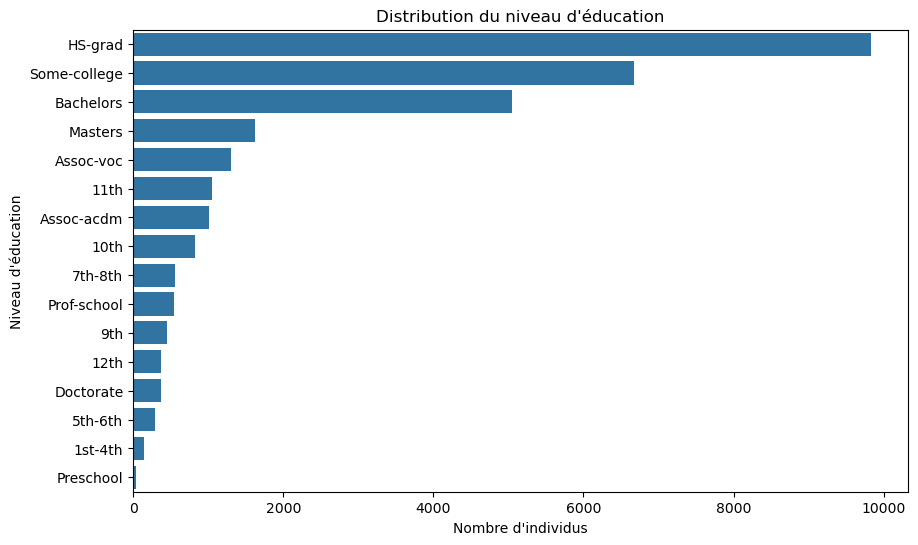

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df['education'], order=df['education'].value_counts().index)
plt.xlabel("Nombre d'individus")
plt.ylabel("Niveau d'éducation")
plt.title("Distribution du niveau d'éducation")
plt.show()


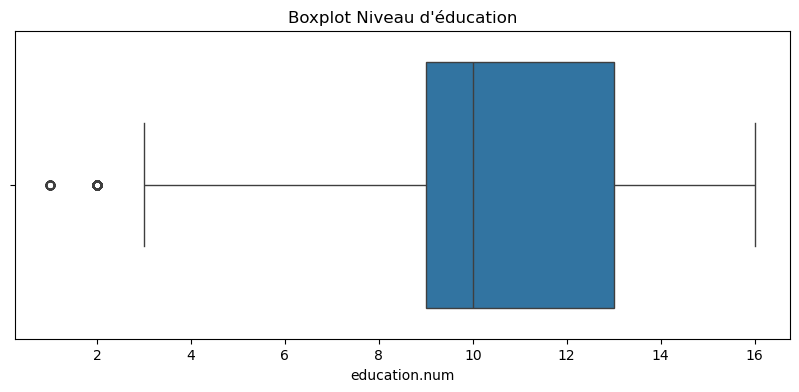

In [42]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["education.num"])
plt.title("Boxplot Niveau d'éducation")
plt.show()


In [43]:
z_scores = np.abs(stats.zscore(df["education.num"]))
df[z_scores > 2.5]

,age,workclass,education,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income,income_num
26,33,Private,1st-4th,2,Married-civ-spouse,Craft-repair,White,Male,0,2603,32,<=50K,0
27,49,Private,5th-6th,3,Married-civ-spouse,Other-service,White,Male,0,2603,40,<=50K,0
142,46,Private,5th-6th,3,Divorced,Craft-repair,White,Female,0,2339,45,<=50K,0
145,61,Private,5th-6th,3,Never-married,Handlers-cleaners,Black,Male,0,2339,40,<=50K,0
161,69,Private,5th-6th,3,Married-civ-spouse,Machine-op-inspct,White,Male,0,2267,40,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32358,24,Private,5th-6th,3,Married-spouse-absent,Farming-fishing,White,Male,0,0,40,<=50K,0
32381,46,Private,Preschool,1,Married-civ-spouse,Machine-op-inspct,Black,Male,0,0,75,<=50K,0
32418,48,Private,1st-4th,2,Married-civ-spouse,Machine-op-inspct,White,Male,0,0,40,<=50K,0
32439,23,Private,1st-4th,2,Married-civ-spouse,Machine-op-inspct,Amer-Indian-Eskimo,Female,0,0,35,<=50K,0


### Interprétation

- **Nombre d’extrêmes** : Le code a détecté **`480 individus`** dont le parcours scolaire est **très éloigné de la moyenne** $Z > 2,5$  
- **Nature des extrêmes** : Ces valeurs correspondent aux **niveaux les plus faibles du système éducatif** :  
  - 1 à 3 années d’études  
  - Niveaux **Preschool** ou **primaire partiel**  
- **Distribution** : Contrairement aux heures de travail, ces extrêmes se trouvent uniquement **vers le bas**, ce qui crée une **asymétrie négative** dans la distribution.  


---

## Analyse Multivariée (L'influenceavec sur la distribution de Income) :

### 1. Âge vs Income

Cette boîte à moustaches compare la distribution de l'âge entre les deux groupes de revenus (<=50K et >50K). Elle nous permet de vérifier si les personnes aux revenus plus élevés sont généralement plus âgées (médiane plus haute) que celles aux revenus plus modestes

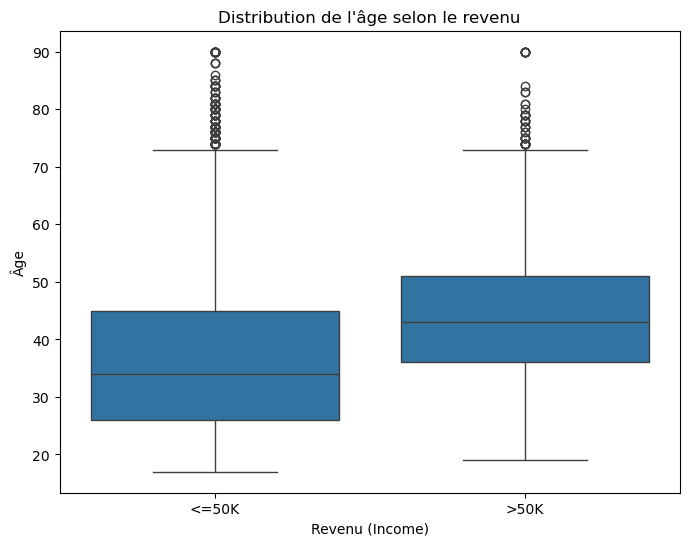

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='age', data=df)
plt.xlabel("Revenu (Income)")
plt.ylabel("Âge")
plt.title("Distribution de l'âge selon le revenu")
plt.show()

### Interprétation

- **Âge et revenu** : Les individus gagnant **>50K** sont en moyenne **plus âgés**.  
- **Conclusion** : Cela suggère un **lien positif entre expérience professionnelle et niveau de revenu**.  

---

### 2. Heures travaillées vs Income

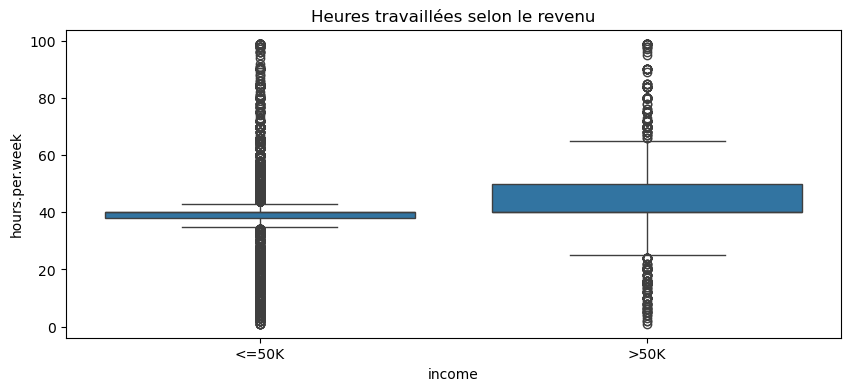

In [45]:
plt.figure(figsize=(10,4))
sns.boxplot(x="income", y="hours.per.week", data=df)
plt.title("Heures travaillées selon le revenu")
plt.show()

### Interprétation

- **Heures de travail et revenu** : Les individus gagnant **>50K** travaillent en moyenne **45h/semaine**, contre **39h** pour le groupe **<=50K**.  
- **Conclusion** : Il existe une **corrélation positive** entre le temps de travail et le revenu, les hauts salaires sont fortement liés à la réalisation d'**heures supplémentaires**.
---

### 3. Éducaton vs Income

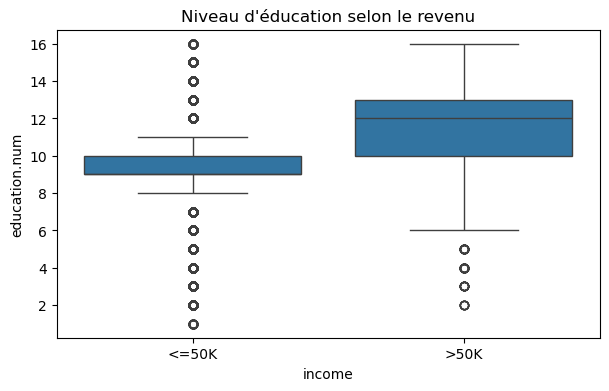

In [46]:
plt.figure(figsize=(7,4))
sns.boxplot(x="income", y="education.num", data=df)
plt.title("Niveau d'éducation selon le revenu")
plt.show()

### Interprétation

- **Éducation et revenu** : Les individus gagnant **>50K** présentent un **niveau d’éducation nettement plus élevé**.  
- **Conclusion** : C’est la **relation la plus marquée** observée dans le dataset.  
---

<center>
    <h1>Distribution et ajustement de loi de probabilité</h1>
</center>

Nous allons étudier la distribution de la variable **`"age"`**. L'objectif est de voir si cette variable suit une distribution connue.

**Observation Graphique :**
L'histogramme de l'âge montre une distribution **unimodale** (en forme de cloche) avec une légère asymétrie positive, ce qui rappelle la forme d'une gaussienne.

**Arguments pour la Loi Normale :**
- **`Symétrie des données :`** L'espérance mathématique ($\mu \approx 38.4$) est très proche de la médiane ($37$). Cette proximité confirme que la distribution est globalement symétrique.
- **`Théorème Central Limite (TCL) :`** L'âge d'un individu dans la population active dépend d'une multitude de facteurs indépendants (durée d'études, santé, contexte économique). Selon le TCL, la somme de ces effets indépendants tend naturellement vers une loi Normale.
- **`Robustesse :`** Avec un échantillon de grande taille ($n > 30\,000$), l'approximation par une loi continue est statistiquement valide.

**Modèle Retenu :**
Nous validons donc l'ajustement par une **Loi Normale** avec les paramètres estimés suivants :

$$X_{age} \sim \mathcal{N}(\mu=38.4, \sigma^2=13.1^2)$$

Paramètres estimés : Moyenne (mu) = 38.44, Écart-type (std) = 13.13


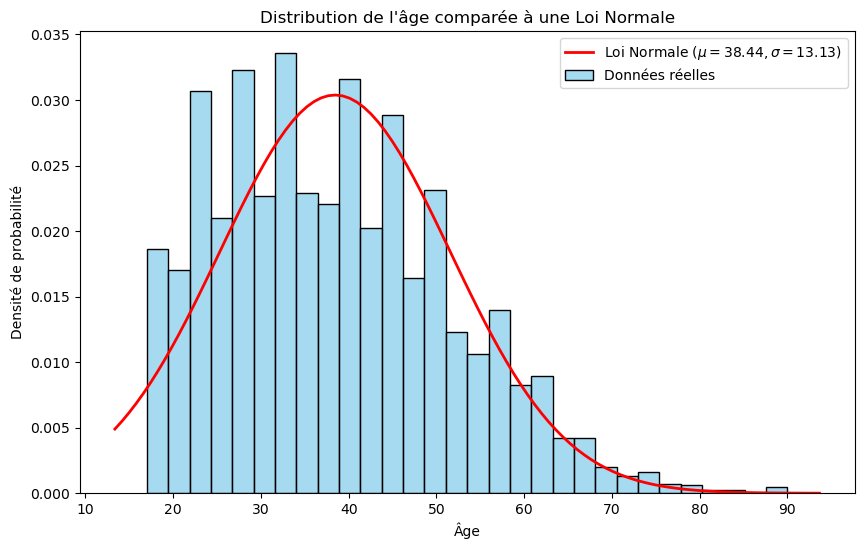

In [47]:
data_variable = df['age'].dropna()

mu, std = norm.fit(data_variable)
print(f"Paramètres estimés : Moyenne (mu) = {mu:.2f}, Écart-type (std) = {std:.2f}")

plt.figure(figsize=(10, 6))

sns.histplot(data_variable, kde=False, stat="density", color='skyblue', label="Données réelles", bins=30)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2, label=f'Loi Normale ($\mu={mu:.2f}, \sigma={std:.2f}$)')

plt.title("Distribution de l'âge comparée à une Loi Normale")
plt.xlabel("Âge")
plt.ylabel("Densité de probabilité")
plt.legend()
plt.show()

### Interprétation
En observant le graphique ci-dessus, nous pouvons faire les constats suivants :

-  **Forme de la distribution** : L'histogramme (en bleu) montre que la distribution de l'âge est **asymétrique à droite**. Il y a une concentration plus forte d'individus jeunes (20-40 ans) et une queue qui s'étire vers les âges plus avancés.
-  **Comparaison avec la Loi Normale** : La courbe rouge `(Loi Normale théorique)` est parfaitement symétrique. On voit clairement un décalage :
    - Le pic réel est plus `"pointu"` et situé `plus à gauche` que le pic de la courbe normale.
    - La loi normale sous-estime le nombre de jeunes adultes et sur-estime le nombre de personnes d'âge moyen (50-60 ans)
---

<center>
    <h1>Tests Statistiques et Modélisation</h1>
</center>

### Test de Normalité `(Shapiro-Wilk)`
Le graphique ci-dessus nous donne une intuition visuelle. Pour être rigoureux, nous utilisons un test statistique.
* **Hypothèse Nulle ($H_0$)** : La distribution suit une loi Normale.
* **Hypothèse Alternative ($H_1$)** : La distribution ne suit pas une loi Normale.

*Note : Comme notre dataset est très grand (>30 000 lignes), les tests statistiques sont très sensibles. Nous ferons le test sur un échantillon aléatoire de 500 individus.*

In [48]:
# Le test de Shapiro-Wilk est connu pour être excessivement sensible aux grands effectifs. 
# pour obtenir un diagnostic plus équilibré sur la normalité de la distribution, On va utiliser un échantillon aléatoire de 500 individu

data_sample = df['age'].sample(500)
stat, p_value = shapiro(data_sample)

print(f"Statistique de test : {stat:.3f}")
print(f"p-value : {p_value:.4f}")

if p_value > 0.05:
    print("On ne peut pas rejeter l'hypothèse nulle : l'âge suit probablement une Loi Normale.")
else:
    print("On rejette l'hypothèse nulle : l'âge ne suit pas strictement une Loi Normale (asymétrie).")

Statistique de test : 0.971
p-value : 0.0000
On rejette l'hypothèse nulle : l'âge ne suit pas strictement une Loi Normale (asymétrie).


### Interprétation

Le test de **`Shapiro-Wilk`** indique que la distribution de l’âge **n’est pas normale**.  

- **Résultat** : La **`p - value`** est très faible `(< 0,05)`, conduisant au rejet de $H_0$.  
- **Analyse** : Cette observation est cohérente avec l’asymétrie visuelle. Sur de grands datasets, le test est très sensible, mais cela **n’affecte pas la modélisation**, car la régression logistique **ne nécessite pas la normalité des variables**.  
---

<center>
    <h1>Modélisation Prédictive : Régression Logistique</h1>
</center>

Nous allons tenter de prédire si une personne gagne plus de 50K ou non, en fonction de ses caractéristiques (âge, niveau d'éducation, heures de travail, etc.)

C'est un problème de **classification binaire**.
-  **Target** : `income` (transformé en 0 ou 1).
-  **Features** : Variables numériques (`age`, `education.num`, `hours.per.week`, etc.).

In [49]:
X = df[["age", "education.num", "hours.per.week"]]
y = df["income_num"]
model_log = LogisticRegression()
model_log.fit(X, y)
for var, coef in zip(X.columns, model_log.coef_[0]):
    print(f"Coefficient pour {var} : {coef:.4f}")

Coefficient pour age : 0.0484
Coefficient pour education.num : 0.3445
Coefficient pour hours.per.week : 0.0418


### interpretation
- L'Éducation (0.34) : C'est  `accélérateur principal`. Une augmentation du niveau d'étude booste énormément la probabilité de gagner plus de 50K.
- L'Âge (0.048) & Le Travail (0.041) : Ce sont des contributeurs secondaires. Ils tirent le revenu vers le haut, mais beaucoup plus lentement que les diplômes.

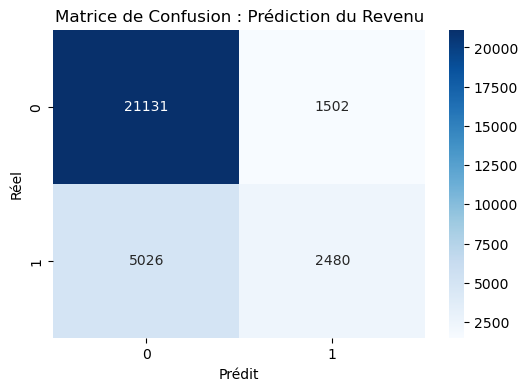

In [50]:
y_pred = model_log.predict(X)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion : Prédiction du Revenu")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

### Analyse Détaillée de la Matrice de Confusion

Voici la lecture des résultats de notre modèle sur l'échantillon de test :

* **Vrais Négatifs (21 131)** :
    * Le modèle a correctement prédit que ces personnes gagnent **`≤50K`**. C'est la catégorie la mieux détectée.
    
* **Vrais Positifs (2 480)** :
    * Le modèle a correctement identifié ces personnes comme gagnant **`>50K`**.

* **Faux Positifs (1 502)** :
    * Le modèle a prédit à tort que ces personnes étaient riches `(>50K)`, alors qu'elles gagnent moins.

* **Faux Négatifs (5 026)** :
    * Le modèle a "raté" ces personnes riches en les classant par erreur dans la catégorie `≤50K`. C'est l'erreur la plus fréquente, due au déséquilibre des classes.

In [51]:
precision = accuracy_score(y, y_pred)
print(f"Précision du modèle : {precision:.2%}")

Précision du modèle : 78.34%


### Interprétation

Nous avons entraîné une Régression Logistique pour prédire si un individu gagne plus de 50K/an.

-  **Performance Globale (Accuracy)** :
    * Le modèle obtient une précision d'environ **`78.34%`**
    * Cela signifie que dans 4 cas sur 5, le modèle arrive à deviner correctement la catégorie de revenu juste en connaissant l'âge, l'éducation et les heures de travail.

-  **Conclusion du Projet : `Les variables socio-démographiques (Éducation, Âge, Capital) sont de puissants indicateurs du niveau de revenu.`**